<h4> Exercise1: Define a function that takes as arguments two vectors and calculate the cosine of angle between them. Check whether vectors $x_1 = [3,1, -2,4]$ and $x_2=[-1,3,4,2]$ are orthogonal.

In [21]:
import numpy as np

x1 = np.array([3, 1, -2, 4])
x2 = np.array([-1, 3, 4, 2])

def is_orthogonal(vec1, vec2):

    cosin = round(np.dot(vec1, vec2) / np.linalg.norm(vec1) * np.linalg.norm(vec2), 100)
    return cosin



if is_orthogonal(x1, x2) == 0: print(f"Orthogonal") 
else: print("Not orthogonal")

Orthogonal


Exercise2: Check whether the matrix above is in fact, the inverse of $A$ by calculating $A\cdot A^{-1}$. What should you obtain?

In [22]:
A = np.array([[2,3],[1,2]])
A_inv = np.linalg.inv(A)

I = np.dot(A, A_inv)

if np.array_equal(I, np.identity(2)):
    print("True")
else:
    print("False")

True


Exercise3: Define two square matrices $A$ and $B$ and calculate $A\cdot B+B^T$.
    
    
$A = \begin{bmatrix} 1 & 2 & 1 \\ 3 & 0 & 1 \\ 0 & 2 & 4 \end{bmatrix}$, $B = \begin{bmatrix} -1 & 0 & 1 \\ 2 & 1 & 0 \\ 3 & -2 & 1 \end{bmatrix}$

In [23]:
A= np.array([[1, 2, 1], [3,0,1], [0,2,4]])
B=np.array([[-1,0,1], [2,1,0], [3,-2,1]])

C= np.dot(A, B)+np.transpose(B)
print(C)

[[ 5  2  5]
 [ 0 -1  2]
 [17 -6  5]]


<h4> Exercise4: For the example above, what is the $cov(X,Y)$?. According to this matrix, calculate the correlation coefficient. Interpret it.

In [24]:
x = np.linspace(-2,2,10) #domain, from -2 to 2, 10 numbers   
y = -3*x+4+ np.random.normal(0,1, 10)         #function

cov = np.cov(x,y)
print(f"Covariance matrix: {cov}")

covXY= cov[0,1]
print(f"XY covariance: {round(covXY, 2)}")

cor = covXY / (np.sqrt(cov[0,0])*np.sqrt(cov[1,1]))
print(f"Correlation coefficient: {round(cor, 2)}")

Covariance matrix: [[ 1.81069959 -5.68485992]
 [-5.68485992 18.17390727]]
XY covariance: -5.68
Correlation coefficient: -0.99


Exercise5: To rotate a vector $v$ one may multiply the matrix $A = \begin{bmatrix} \cos \theta & \sin \theta \\ -\sin \theta & \cos \theta  \end{bmatrix}$ by it (i.e. $Av$), where $\theta$ is an angle of rotation. Define a vector $[-3,4]$ which starts in the origin of coordiantes. Rotate it ($\theta = 30^o$) and plot both vectors.

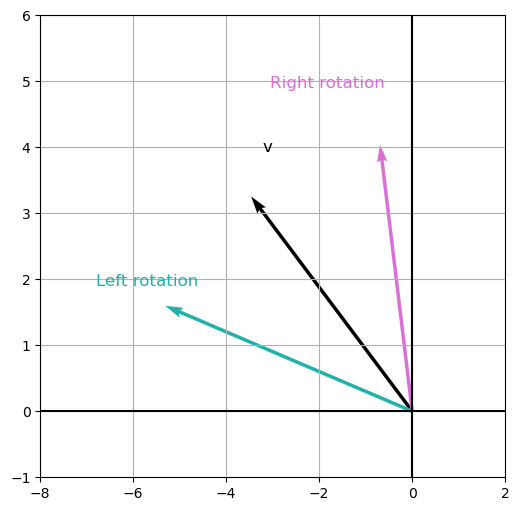

In [25]:
import matplotlib.pyplot as plt
v = np.array([-3,4])
def rotation_matrix(angle):
    x = np.array([[np.cos(angle), np.sin(angle)], [-np.sin(angle), np.cos(angle)]])
    return x

x =rotation_matrix(np.pi/6)
v_Rrot = np.dot(rotation_matrix(np.pi/6),v)
v_Lrot = np.dot(v, rotation_matrix(np.pi/6))

fig, ax = plt.subplots(figsize=(6, 6))
#ax.quiver(*origin, *vector, angles='xy', scale_units='xy', scale=1, color='b')
ax.quiver(0, 0, v[0],  v[1],units='xy' ,scale=1) 
ax.quiver(0, 0, v_Rrot[0],  v_Rrot[1],units='xy' ,scale=1, color = "orchid") 
ax.quiver(0, 0, v_Lrot[0],  v_Lrot[1],units='xy' ,scale=1, color = "lightseagreen") 
ax.grid()

#labels
ax.text(v[0], v[1], 'v', fontsize=12, color='black', ha='right', va='center')
ax.text(v_Rrot[0], v_Rrot[1], 'Right rotation', fontsize=12, color='orchid', ha='right', va='center')
ax.text(v_Lrot[0], v_Lrot[1], 'Left rotation', fontsize=12, color='lightseagreen', ha='right', va='center')

#plot size
plt.xlim(-8,2)
plt.ylim(-1,6)

#ax.set_aspect('equal')

#add x,y axis
ax.axhline(color='black')
ax.axvline(color="black")
plt.show()


Exercise6: Given a random variable $X \sim N(0,1)$ calculate $P(X<1)$, $P(X>1)$ and $P(-1<X<2)$.

In [2]:
import statistics
from scipy.stats import norm 

#P(X<=1) for X~N(0,1); P(X=1) =0
x = norm.cdf(1)
print(f"P(X<1): ", round(x,3))

# 1 - P(X<=1) = P(X>1)
x2 =1-x
print(f"P(X>1): ", round(x2,3))

# P(X<2)
y = norm.cdf(2)

## P(X<-1)
y1= norm.cdf(-1)

# P(-1< X< 2)
y3=y-y1
print(f"P(-1<X<2): ", round(y3,3))

P(X<1):  0.841
P(X>1):  0.159
P(-1<X<2):  0.819


Exercise7: Suppose in a given population the height may be described as a random variable $X \sim N(170, 10)$. What is the percent of people who have the height between 160 and 190?

In [3]:
#F(t) = P(X <= t)
x = norm.cdf(190, loc =170, scale = 10) #F(190) for X~N(170,10); X<=190
x2 = norm.cdf(160, loc =170, scale = 10) #X<=160

# 160 < X < 190
x3 =x-x2
print(round(x3,3))

0.819


Exercise8: A company is analyzing emails to determine the probability that a given email is spam if it contains the word "win". It collected the following data:

Based on the data, determine:
    
- the probability an email is spam $P(S)$
    
- the probability of containing a word "win" provided a message is a spam $P("win"|S)$
- the probability of containing a word "win" provided a message is not a spam $P("win"|NS)$
    
What is the probability that an email is a spam, given that it contains the word "win"? $P(S|"win")$. Calculate it directly and by using Bayesian Theorem.

In [28]:
d = [('NS', False), ('NS', False), ('S', False), ('NS', False), ('NS', True), ('NS', False), ('S', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', True), ('S', True), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', True), ('NS', False), ('S', True), ('NS', False), ('S', False), ('S', True), ('NS', False), ('S', True), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', False), ('S', False), ('NS', False), ('NS', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', True), ('S', False), ('NS', False), ('NS', False), ('NS', True), ('NS', False), ('NS', False), ('NS', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', True), ('S', True), ('NS', False), ('S', False), ('S', False), ('NS', False), ('NS', False), ('NS', False), ('NS', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False)]
print(d)

total = len(d)
spam = len([label for label, tag in d if label == "S"])
notspam = total -spam
print(total, spam, notspam)

#P(S)
p_s = spam/total
print(f"P(S) = {p_s}")

#P("win"/S)
s_win = len([label for label, tag in d if label == "S" and tag == True])
p_win_s = s_win/spam
print(f"P(\"win\"/S): {p_win_s}")

#P("win"/NS)
ns_win = len([label for label, tag in d if label == "NS" and tag == True])
p_win_ns = ns_win/notspam
print(f"P(\"win\"/NS): {p_win_ns}")

#P(S/"win") = P("win"∣S)⋅P(S) / P("win")
p_win = len([label for label, tag in d if tag == True])/total


p_s_win = p_win_s * p_s / p_win
print(f"P(S/\"win\") = {p_s_win}")


[('NS', False), ('NS', False), ('S', False), ('NS', False), ('NS', True), ('NS', False), ('S', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', True), ('S', True), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', True), ('NS', False), ('S', True), ('NS', False), ('S', False), ('S', True), ('NS', False), ('S', True), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', False), ('S', False), ('NS', False), ('NS', True), ('NS', False), ('NS', False), ('NS', False), ('NS', False), ('S', True), ('S', False), ('NS', Fa

Exercise9: Consider the following height data in two populations - $P_1$ and $P_2$.

<h4> Assume in both populations the height has normal distribtuion. 

    
- estitmate distributions parameters (based ond means and standard deviations)
- determine to which group (probably) a person who has 160 belongs to
- determine to which group (probably) a person who has 165 belongs to
- determine to which group (probably) a person who has 173 belongs to

In [29]:
import matplotlib.pyplot as plt
import statistics as st

data = [('p1', 178.46), ('p1', 171.58), ('p2', 152.96), ('p2', 148.92), ('p1', 195.19), ('p2', 150.78), ('p1', 176.33), ('p1', 167.77), ('p2', 157.42), ('p1', 158.5), ('p2', 154.23), ('p1', 164.32), ('p1', 170.9), ('p1', 175.8), ('p1', 174.4), ('p2', 158.17), ('p1', 161.3), ('p1', 189.98), ('p1', 166.66), ('p1', 177.61), ('p1', 166.0), ('p2', 154.7), ('p1', 166.15), ('p2', 161.93), ('p2', 157.65), ('p1', 162.41), ('p1', 166.94), ('p1', 153.97), ('p1', 161.03), ('p1', 168.84), ('p1', 178.26), ('p2', 164.13), ('p2', 154.79), ('p1', 166.99), ('p1', 165.03), ('p1', 165.24), ('p1', 186.21), ('p1', 181.89), ('p1', 160.76), ('p1', 181.06), ('p1', 179.48), ('p2', 157.88), ('p2', 156.49), ('p2', 163.57), ('p2', 158.5), ('p1', 173.76), ('p1', 156.87), ('p1', 189.63), ('p2', 168.45), ('p2', 160.94), ('p1', 169.36), ('p2', 159.43), ('p2', 159.43), ('p1', 166.24), ('p2', 163.98), ('p2', 142.77), ('p1', 171.57), ('p1', 192.71), ('p2', 168.96), ('p1', 155.96), ('p2', 143.28), ('p2', 182.12), ('p2', 144.3), ('p1', 169.13), ('p1', 176.34), ('p2', 154.05), ('p1', 175.59), ('p1', 160.09), ('p1', 159.16), ('p1', 159.5), ('p2', 148.88), ('p2', 144.91), ('p1', 180.93), ('p2', 165.41), ('p2', 151.08), ('p1', 173.76), ('p1', 163.51), ('p2', 166.51), ('p2', 148.07), ('p1', 159.95), ('p1', 165.78), ('p1', 168.66), ('p1', 174.13), ('p1', 162.41), ('p2', 138.7), ('p1', 173.14), ('p2', 143.03), ('p1', 159.47), ('p2', 139.14), ('p1', 158.82), ('p2', 147.73), ('p2', 160.3), ('p1', 160.0), ('p1', 188.51), ('p1', 161.37), ('p1', 169.68), ('p2', 155.67), ('p2', 157.35), ('p1', 149.62), ('p1', 183.45), ('p1', 173.27), ('p2', 146.69), ('p1', 171.13), ('p2', 163.92), ('p2', 169.85), ('p2', 159.29), ('p1', 170.31), ('p2', 173.83), ('p2', 162.65), ('p1', 169.83), ('p1', 173.21), ('p2', 181.41), ('p1', 176.2), ('p2', 161.09), ('p1', 174.23), ('p1', 167.77), ('p1', 167.04), ('p1', 160.95), ('p2', 162.47), ('p2', 164.4), ('p2', 174.46), ('p1', 169.89), ('p1', 155.88), ('p2', 151.6), ('p1', 168.04), ('p2', 173.8), ('p1', 192.41), ('p1', 161.99), ('p2', 155.73), ('p2', 157.97), ('p1', 153.93), ('p1', 173.21), ('p2', 150.26), ('p1', 181.24), ('p2', 160.81), ('p1', 150.65), ('p2', 163.86), ('p1', 173.39), ('p1', 153.41), ('p2', 150.77), ('p2', 153.46), ('p1', 177.17), ('p2', 170.38), ('p1', 160.57), ('p1', 147.83), ('p2', 138.39), ('p2', 153.98), ('p2', 145.62), ('p2', 168.29), ('p2', 153.45), ('p2', 162.17), ('p1', 175.83), ('p1', 178.8), ('p2', 159.27), ('p1', 174.79), ('p2', 156.27), ('p2', 156.64), ('p1', 175.39), ('p1', 169.8), ('p2', 149.33), ('p2', 182.76), ('p2', 158.84), ('p1', 175.01), ('p1', 175.41), ('p2', 156.73), ('p1', 166.13), ('p1', 173.1), ('p2', 140.1), ('p2', 165.41), ('p1', 179.24), ('p2', 174.09), ('p1', 155.33), ('p2', 160.75), ('p1', 171.18), ('p2', 168.74), ('p1', 163.51), ('p1', 175.81), ('p1', 163.63), ('p2', 160.77), ('p2', 153.78)]

#estitmate distributions parameters (based ond means and standard deviations)
p1 = [height for pop, height in data if pop == "p1"]
p2 = [height for pop, height in data if pop == "p2"]

mu_p1, sigma_p1 = st.mean(p1), st.stdev(p1)
mu_p2, sigma_p2 = st.mean(p2), st.stdev(p2)

p_p1 = len(p1)/ len(data)
p_p2 = len(p2)/ len(data)

#determine to which group (probably) a person who has 160 belongs to
#determine to which group (probably) a person who has 165 belongs to
#determine to which group (probably) a person who has 173 belongs to

def bayes(value):
    pdf_p1 = norm.pdf(value, mu_p1, sigma_p1)
    pdf_p2 = norm.pdf(value, mu_p2, sigma_p2)
    ratio = (pdf_p1*p_p1) / (pdf_p2*p_p2)
    return ratio

heights = [160,165,173]

for h in heights:
    if bayes(h) > 1:
        print(f"Height {h} is more probable in group P1")
    else: 
        print(f"Height {h} is more probable in group P2")

Height 160 is more probable in group P2
Height 165 is more probable in group P1
Height 173 is more probable in group P1


Exercise10: Define a PDF for 2D normal distribution given by $f(X) = \frac{1}{2\pi\sqrt{\det(\Sigma)}}\cdot \exp(-\frac{1}{2}(X-\mu)^T\Sigma^{-1}(X-\mu))$, where $X = [X_1, X_2]$, $\mu = [\mu_1,\mu_2]$ and $\Sigma$ is a covariance matrix. Both $\mu$ and $\Sigma$ are parameters.

In [30]:
import numpy as np


def PDF (X, mu, Sigma):
    # X: punkt dla ktr obliczamy pdf
    # mu: średnie
    # Sigma: macierz covariancji 
    X= np.array(X)
    mu = np.array(mu)
    Sigma = np.array(Sigma)

    frac = 1 / (2*np.pi*np.sqrt(np.linalg.det(Sigma)))
    expp = (-0.5)*np.dot(np.dot(np.transpose(X- mu),np.linalg.inv(Sigma)),X-mu)

    return frac*np.exp(expp)

#test
X = [1, 2]
mu = [2, 2]
Sigma = [[1, 0.76], 
         [0.76, 2]]

print(PDF(X, mu, Sigma))


0.06606692869394898


Exercise11: We consider two features (represented as a vector) $[X_1,X_2]$ in a population. It appears its distribution may be characterized by normal distribution with $\mu=[1,2]$ and $$\Sigma = \begin{bmatrix} 1 & 1.1 \\ 1.1 & 4  \end{bmatrix}$$ Plot 2D PDF

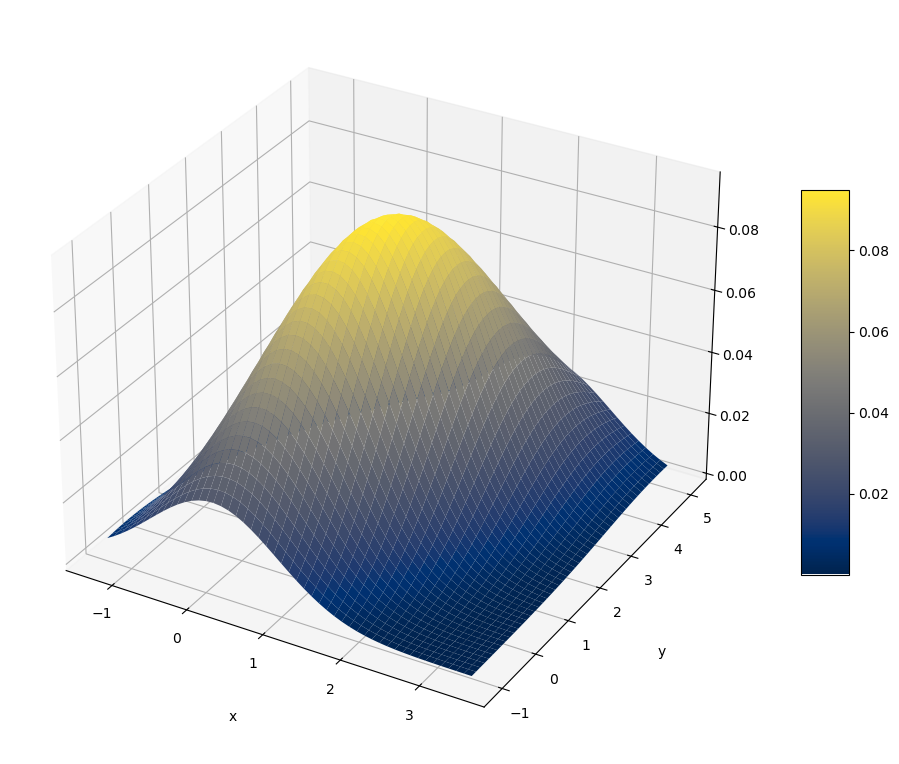

In [ ]:
#how to generate observations (X1, X2) from such distribution
means = np.array([1,2])
sigma_cov = np.array([[1,1.1],[1.1,4]])
data = np.random.multivariate_normal(means, sigma_cov, 10) #generate 10 pairs (x,y) from 2D normal distribution

#PDF dla każdego punktu w data
PDF_list = np.array([PDF(elem, means, sigma_cov) for elem in data])

#z tym wychodzą krzywe wykresy:(
# x= np.array([elem1 for elem1, elem2 in data])
# y= np.array([elem2 for elem1, elem2 in data])

# znajuje najmniejszy i najwiekszy puntk w data i tworzy 50 równo rozłożonych punktow
x = np.linspace(min(data[:,0]), max(data[:,0]), 50)  # data[:,0]) wiersze 1 kolumy (x)
y = np.linspace(min(data[:,1]), max(data[:,1]), 50)  # data[:,1]) wiersze 2 kolumy (y)

X, Y = np.meshgrid(x, y)

# PDF dla każdego punktu w siatce
Z = np.zeros_like(X)   #macierz w kszatłcie X
for i in range(X.shape[0]):  #liczba wierszy
    for j in range(X.shape[1]): #liczba kolumn
        Z[i, j] = PDF([X[i, j], Y[i, j]], means, sigma_cov)

fig = plt.figure(figsize = (12,10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap = plt.cm.cividis)

ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('z', labelpad=20)

fig.colorbar(surf, shrink=0.5, aspect=8)

plt.show()